In [ ]:
def build_vgg_blur_bin5(preprocessing_layer):
    l2_reg = regularizers.l2(1e-4)

    # 1. Define Binomial-5 Kernel (Outer product of [1, 4, 6, 4, 1])
    v = np.array([1, 4, 6, 4, 1], dtype='float32')
    kernel_5x5 = np.outer(v, v)
    kernel_5x5 /= kernel_5x5.sum()

    # 2. Weight helper for DepthwiseConv2D
    def get_bin5_weights(channels):
        w = np.zeros((5, 5, channels, 1), dtype='float32')
        for i in range(channels):
            w[:, :, i, 0] = kernel_5x5
        return w

    # 3. Helper to build a VGG block with BlurPooling
    def vgg_block(x, filters, num_convs, block_id):
        for i in range(num_convs):
            x = layers.Conv2D(filters, (3, 3), padding='same',
                              kernel_initializer='he_normal',
                              kernel_regularizer=l2_reg,
                              name=f'block{block_id}_conv{i+1}')(x)
            x = layers.BatchNormalization(name=f'block{block_id}_bn{i+1}')(x)
            x = layers.Activation('relu', name=f'block{block_id}_relu{i+1}')(x)

        # Insert Bin-5 Blur before MaxPooling
        x = layers.DepthwiseConv2D(kernel_size=5, strides=1, padding='same', use_bias=False,
                                   depthwise_initializer=tf.keras.initializers.Constant(get_bin5_weights(filters)),
                                   trainable=False,
                                   name=f'block{block_id}_blur')(x)
        x = layers.MaxPooling2D(pool_size=(2, 2), name=f'block{block_id}_pool')(x)
        return x

    # --- Construct Model ---
    inputs = layers.Input(shape=(28, 28, 1))
    x = preprocessing_layer(inputs)

    # VGG Configuration: (filters, num_convs)
    # Using 3 blocks for EMNIST (28->14->7->3)
    x = vgg_block(x, 32,  num_convs=2, block_id=1)
    x = vgg_block(x, 64, num_convs=2, block_id=2)
    x = vgg_block(x, 128, num_convs=3, block_id=3)

    # Classification Head
    x = layers.Flatten()(x)
    x = layers.Dense(256, kernel_initializer='he_normal',
                     kernel_regularizer=l2_reg)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(10, activation='softmax')(x)

    model = models.Model(inputs, outputs, name="VGG_Bin5_EMNIST")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


In [1]:
# Load the model
from tensorflow.keras.models import load_model

loaded_model = load_model('/content/emnist_best_model.keras')
print("model loaded successfully")
loaded_model.summary()

model loaded successfully


Model: "VGG_Bin5_EMNIST"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ preprocessing_head (Sequential) │ (None, 28, 28, 1)      │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_bn1 (BatchNormalization) │ (None, 28, 28, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_relu1 (Activation)       │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_bn2 (BatchNormalization) │ (None, 28, 28, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_relu2 (Activation)       │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_blur (DepthwiseConv2D)   │ (None, 28, 28, 32)     │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_bn1 (BatchNormalization) │ (None, 14, 14, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_relu1 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_bn2 (BatchNormalization) │ (None, 14, 14, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_relu2 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_blur (DepthwiseConv2D)   │ (None, 14, 14, 64)     │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_bn1 (BatchNormalization) │ (None, 7, 7, 128)      │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_relu1 (Activation)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 7, 7, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_bn2 (BatchNormalization) │ (None, 7, 7, 128)      │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_relu2 (Activation)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 7, 7, 128)      │       147,58

 Total params: 2,207,523 (8.42 MB)

 Trainable params: 733,418 (2.80 MB)

 Non-trainable params: 7,267 (28.39 KB)

 Optimizer params: 1,466,838 (5.60 MB)

In [2]:
import os
import shutil
import random
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks, regularizers
from sklearn.metrics import (roc_curve, auc, precision_recall_curve,
                             average_precision_score, confusion_matrix,
                             classification_report, accuracy_score)
from sklearn.preprocessing import label_binarize
import kagglehub

# Download latest version
path = kagglehub.dataset_download("osamaaslam86004/greyscale-synthetic-font-digits-blanaced")
path = os.path.join(path, "greyscale_synthetic_digits")
print("Path to dataset files:", path)

# Original DATA_DIR from the download, assuming it holds folders '0' through '9'
original_data_root = path

# Target directory for the processed dataset in /content
target_base_dir = "/content"
train_target_dir = os.path.join(target_base_dir, "train")
test_target_dir = os.path.join(target_base_dir, "test")

# Create target base directories
os.makedirs(train_target_dir, exist_ok=True)
os.makedirs(test_target_dir, exist_ok=True)

print(f"Creating training data in: {train_target_dir}")
print(f"Creating testing data in: {test_target_dir}")

# Define the split ratio and seed for reproducibility
test_split_ratio = 0.2
seed = 42
random.seed(seed)

# Iterate through each digit class (0-9)
for digit in range(10):
    source_digit_dir = os.path.join(original_data_root, str(digit))
    if not os.path.exists(source_digit_dir):
        print(f"Warning: Directory {source_digit_dir} not found. \
        Skipping digit {digit}.")
        continue

    # Create target subdirectories for each digit within train and test
    os.makedirs(os.path.join(train_target_dir, str(digit)), exist_ok=True)
    os.makedirs(os.path.join(test_target_dir, str(digit)), exist_ok=True)

    # Get all image files for the current digit (assuming PNG format)
    image_files = [f for f in os.listdir(source_digit_dir) if f.endswith('.png')]
    random.shuffle(image_files)

    # Split files into train and test sets based on the ratio
    num_test_samples = int(len(image_files) * test_split_ratio)
    test_files = image_files[:num_test_samples]
    train_files = image_files[num_test_samples:]

    print(f"Digit {digit}: {len(train_files)} training samples, \
    {len(test_files)} testing samples.")

    # Copy files to their respective destinations
    for fname in train_files:
        shutil.copy(os.path.join(source_digit_dir, fname), \
                    os.path.join(train_target_dir, str(digit), fname))
    for fname in test_files:
        shutil.copy(os.path.join(source_digit_dir, fname), \
                    os.path.join(test_target_dir, str(digit), fname))

print("Data splitting and copying complete.")

# Update DATA_DIR to point to the newly created dataset in /content
DATA_DIR = target_base_dir
print(f"Updated DATA_DIR to: {DATA_DIR}")



100%|██████████| 49.9M/49.9M [00:01<00:00, 28.9MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/osamaaslam86004/greyscale-synthetic-font-digits-blanaced/versions/1/greyscale_synthetic_digits
Creating training data in: /content/train
Creating testing data in: /content/test
Digit 0: 8554 training samples,     2138 testing samples.
Digit 1: 8554 training samples,     2138 testing samples.
Digit 2: 8554 training samples,     2138 testing samples.
Digit 3: 8554 training samples,     2138 testing samples.
Digit 4: 8554 training samples,     2138 testing samples.
Digit 5: 8554 training samples,     2138 testing samples.
Digit 6: 8554 training samples,     2138 testing samples.
Digit 7: 8554 training samples,     2138 testing samples.
Digit 8: 8554 training samples,     2138 testing samples.
Digit 9: 8554 training samples,     2138 testing samples.
Data splitting and copying complete.
Updated DATA_DIR to: /content


In [ ]:
import shutil
from google.colab import files

# Define the directories to zip
train_dir = "/content/train"
test_dir = "/content/test"

# Define the output zip file names
train_zip_path = "/content/train_data.zip"
test_zip_path = "/content/test_data.zip"

print("Zipping training data...")
shutil.make_archive(base_name='/content/train_data', format='zip', root_dir=train_dir)
print("Training data zipped successfully to /content/train_data.zip")

print("Zipping testing data...")
shutil.make_archive(base_name='/content/test_data', format='zip', root_dir=test_dir)
print("Testing data zipped successfully to /content/test_data.zip")

print("Initiating downloads...")
files.download(train_zip_path)
files.download(test_zip_path)
print("Download initiated for train_data.zip and test_data.zip.")

In [3]:
# Download latest version
# DATA_DIR = DATA_DIR = "/kaggle/input/datasets/osamaaslam86004/greyscale-synthetic-font-digits-blanaced/greyscale_synthetic_digits"

DATA_DIR = "/content"
print("Path to dataset files:", DATA_DIR)

def get_keras_dataset():
    print("--- Loading EMNIST Digits from local PNG folders ---")

    # Global access and constants
    IMG_SIZE = (28, 28)
    BATCH_SIZE = 128
    SEED = 42

    # 1. Load TRAIN dataset
    train_ds = tf.keras.utils.image_dataset_from_directory(
        f"{DATA_DIR}/train",
        validation_split=0.2,
        subset="training",
        seed=SEED,
        color_mode="grayscale",
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE
    )

    val_ds = tf.keras.utils.image_dataset_from_directory(
        f"{DATA_DIR}/train",
        validation_split=0.2,
        subset="validation",
        seed=SEED,
        color_mode="grayscale",
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE
    )

    # 2. Load TEST dataset
    test_ds = tf.keras.utils.image_dataset_from_directory(
        directory=f"{DATA_DIR}/test",
        labels="inferred",
        label_mode="int",
        color_mode="grayscale",
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    class_names = train_ds.class_names
    print("Class names:", class_names)

    # 4. Normalization layer (NO augmentation)
    norm_layer = layers.Normalization(axis=None)
    # Adapt on a mapping to ensure the stats are based on [0, 1] range
    norm_layer.adapt(
        train_ds.map(lambda x, y: x / 255.0).take(500)
    )

    preprocessing_model = models.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Rescaling(1./255),
        norm_layer
    ], name="preprocessing_head")

    # 5. Final pipeline
    def finalize(ds, shuffle=False):
        if shuffle:
            ds = ds.shuffle(10000, seed=SEED)
        return ds.prefetch(tf.data.AUTOTUNE)

    train_ds = finalize(train_ds, shuffle=True)
    val_ds = finalize(val_ds)
    test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

    return train_ds, val_ds, test_ds, preprocessing_model

Path to dataset files: /content


In [4]:
# Initialize data loaders
train_data, val_data, test_data, prep_layer = get_keras_dataset()

# # Recompile the model for fine-tuning with a lower learning rate
loaded_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), # Lower LR for fine-tuning
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=6,
                                     restore_best_weights=True,
                                     verbose=1)

reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                        patience=3,
                                        min_lr=1e-6,
                                        verbose=1)

checkpoint = callbacks.ModelCheckpoint("fine_tuned_emnist_model.keras", # New checkpoint name
                                       monitor='val_accuracy',
                                       save_best_only=True,
                                       mode='max',
                                       verbose=1)
# Train
history = loaded_model.fit(
    train_data,
    epochs=250,
    validation_data=val_data,
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1
)

--- Loading EMNIST Digits from local PNG folders ---
Found 85540 files belonging to 10 classes.
Using 68432 files for training.
Found 85540 files belonging to 10 classes.
Using 17108 files for validation.
Found 21380 files belonging to 10 classes.
Class names: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
Epoch 1/250
533/535 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9616 - loss: 0.1700
Epoch 1: val_accuracy improved from None to 0.99392, saving model to fine_tuned_emnist_model.keras

Epoch 1: finished saving model to fine_tuned_emnist_model.keras
535/535 ━━━━━━━━━━━━━━━━━━━━ 40s 37ms/step - accuracy: 0.9803 - loss: 0.0865 - val_accuracy: 0.9939 - val_loss: 0.0289 - learning_rate: 1.0000e-04
Epoch 2/250
533/535 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9933 - loss: 0.0316
Epoch 2: val_accuracy improved from 0.99392 to 0.99591, saving model to fine_tuned_emnist_model.keras

Epoch 2: finished saving model to fine_tuned_emnist_model.keras
535/535 ━━━━━━━━━━━━━━━━━━━━ 16s 1

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2138
           1       1.00      1.00      1.00      2138
           2       1.00      1.00      1.00      2138
           3       1.00      1.00      1.00      2138
           4       1.00      1.00      1.00      2138
           5       1.00      1.00      1.00      2138
           6       1.00      1.00      1.00      2138
           7       1.00      1.00      1.00      2138
           8       1.00      1.00      1.00      2138
           9       1.00      1.00      1.00      2138

    accuracy                           1.00     21380
   macro avg       1.00      1.00      1.00     21380
weighted avg       1.00      1.00      1.00     21380


Accuracy (Test Set): 0.9993


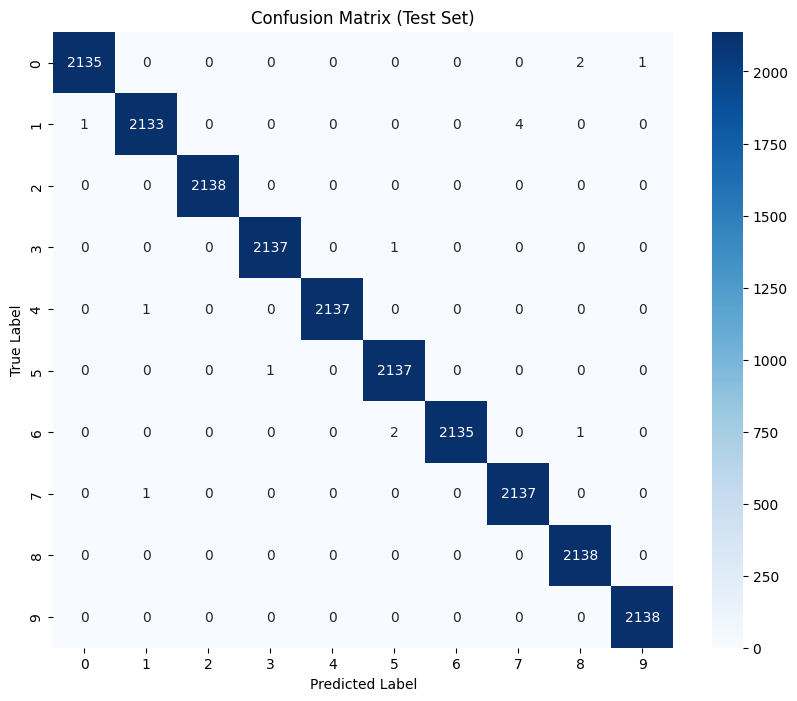

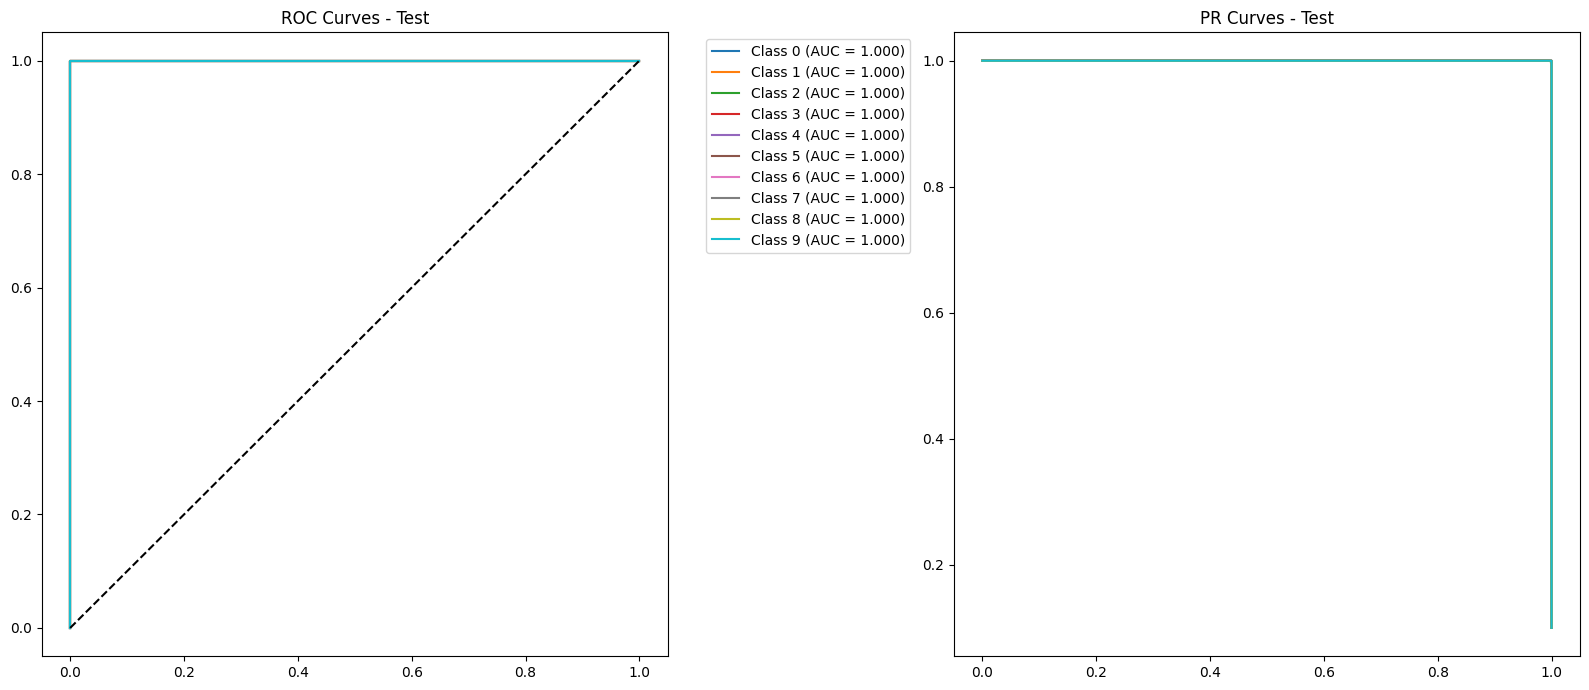

In [5]:
# Evaluation logic
def get_actual_and_probabilities(dataset):
    y_true = []
    y_probs = []
    for images, labels in dataset:
        preds = loaded_model.predict(images, verbose=0)
        y_probs.extend(preds)
        y_true.extend(labels.numpy())
    return np.array(y_true), np.array(y_probs)

def plot_evaluation_curves(y_true_labels, y_probs, class_names, set_name="Test"):
    n_classes = len(class_names)
    y_true_bin = label_binarize(y_true_labels, classes=range(n_classes))

    plt.figure(figsize=(16, 7))
    plt.subplot(1, 2, 1)
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
        plt.plot(fpr, tpr, label=f'Class {class_names[i]} (AUC = {auc(fpr, tpr):.3f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.title(f'ROC Curves - {set_name}')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.subplot(1, 2, 2)
    for i in range(n_classes):
        precision, recall, _ = precision_recall_curve(y_true_bin[:, i], y_probs[:, i])
        plt.plot(recall, precision, label=f'Class {class_names[i]}')
    plt.title(f'PR Curves - {set_name}')
    plt.tight_layout()
    plt.show()

# Final Evaluation
target_names = [str(i) for i in range(10)]
y_test_true, y_test_probs = get_actual_and_probabilities(test_data)

# Get predicted labels for the test set
y_test_pred = np.argmax(y_test_probs, axis=1)

# 1. Print classification report
print("Classification Report (Test Set):")
print(classification_report(y_test_true, y_test_pred, target_names=target_names))

# 2. Print accuracy on test set
accuracy = accuracy_score(y_test_true, y_test_pred)
print(f"\nAccuracy (Test Set): {accuracy:.4f}")

# 3. Plot confusion matrix for test set
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_test_true, y_test_pred),
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=target_names,
            yticklabels=target_names)
plt.title('Confusion Matrix (Test Set)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

plot_evaluation_curves(y_test_true, y_test_probs, target_names, set_name="Test")

#### Plot Entropy Distribuyion

669/669 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


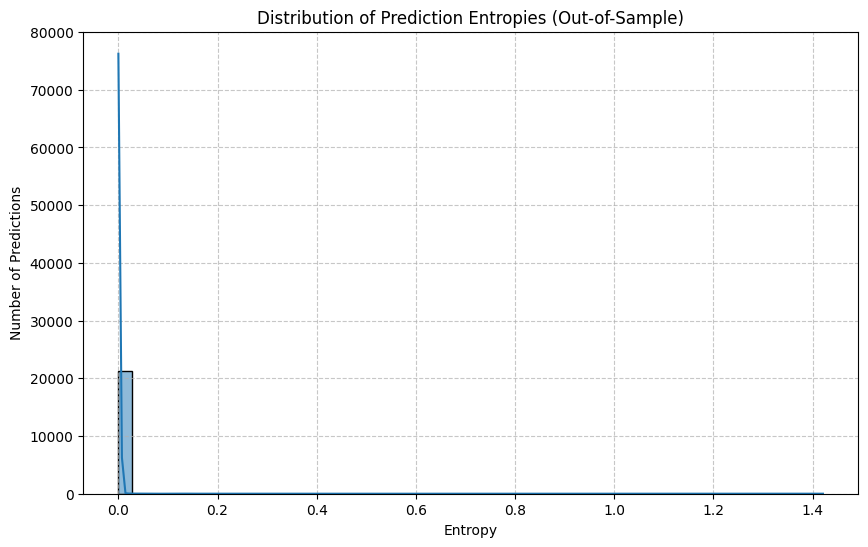

Average Entropy: 0.0011
Min Entropy: 0.0000
Max Entropy: 1.4209

Prediction with Highest Entropy (index 12236):
True Label: 5
Predicted Label: 3
Probabilities: [2.7532349e-03 3.2498872e-01 6.3944369e-04 4.1934568e-01 7.3006854e-04
 5.3985137e-02 1.1726335e-01 1.5838932e-04 5.1235374e-02 2.8900696e-02]
Entropy: 1.4209

Prediction with Lowest Entropy (index 9641):
True Label: 4
Predicted Label: 4
Probabilities: [1.25014649e-19 1.98074039e-17 8.79488206e-18 1.02168986e-22
 1.00000000e+00 3.23550210e-20 6.96415560e-16 6.57099995e-18
 1.86815863e-17 9.87623205e-14]
Entropy: 0.0000


In [6]:
from scipy.stats import entropy

# Extract images and labels from test_data
all_images = []
all_labels = []
for images, labels in test_data:
    all_images.append(images.numpy())
    all_labels.append(labels.numpy())

x_test = np.concatenate(all_images, axis=0)
y_test_true = np.concatenate(all_labels, axis=0)

# Make predictions with the loaded model
y_test_probs = loaded_model.predict(x_test)
y_test_pred = np.argmax(y_test_probs, axis=1)

# Calculate entropy for each prediction
entropies = entropy(y_test_probs, axis=1)

# Plot histogram of entropies
plt.figure(figsize=(10, 6))
sns.histplot(entropies, bins=50, kde=True)
plt.title('Distribution of Prediction Entropies (Out-of-Sample)')
plt.xlabel('Entropy')
plt.ylabel('Number of Predictions')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

print(f"Average Entropy: {np.mean(entropies):.4f}")
print(f"Min Entropy: {np.min(entropies):.4f}")
print(f"Max Entropy: {np.max(entropies):.4f}")

# Example: Find indices of highest and lowest entropy predictions
highest_entropy_idx = np.argmax(entropies)
lowest_entropy_idx = np.argmin(entropies)

print(f"\nPrediction with Highest Entropy (index {highest_entropy_idx}):")
print(f"True Label: {y_test_true[highest_entropy_idx]}")
print(f"Predicted Label: {y_test_pred[highest_entropy_idx]}")
print(f"Probabilities: {y_test_probs[highest_entropy_idx]}")
print(f"Entropy: {entropies[highest_entropy_idx]:.4f}")

print(f"\nPrediction with Lowest Entropy (index {lowest_entropy_idx}):")
print(f"True Label: {y_test_true[lowest_entropy_idx]}")
print(f"Predicted Label: {y_test_pred[lowest_entropy_idx]}")
print(f"Probabilities: {y_test_probs[lowest_entropy_idx]}")
print(f"Entropy: {entropies[lowest_entropy_idx]:.4f}")

### Vector Scalling

#### Define Vector Scaller

In [7]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks, regularizers
from tensorflow.keras.saving import register_keras_serializable, serialize_keras_object, deserialize_keras_object

@register_keras_serializable()
class VectorScaler(tf.keras.Model):
    def __init__(self, model_to_calibrate=None, num_classes=10, **kwargs):
        # Extract custom arguments from kwargs to prevent them from being passed to super().__init__()
        if 'model_to_calibrate' in kwargs:
            model_to_calibrate = kwargs.pop('model_to_calibrate')
        if 'num_classes' in kwargs:
            num_classes = kwargs.pop('num_classes')

        super().__init__(**kwargs) # Call super() with only arguments it expects

        # Now handle your custom arguments
        if isinstance(model_to_calibrate, dict):
            self.model_to_calibrate = deserialize_keras_object(model_to_calibrate)
        elif model_to_calibrate is not None: # Regular instantiation
            self.model_to_calibrate = model_to_calibrate
        else: # Should not happen if constructed correctly
            raise ValueError("model_to_calibrate must be provided during initialization or deserialization.")

        self.num_classes = num_classes
        # Initialize W and b to None; they will be created in the build method.
        self.W = None
        self.b = None

    def build(self, input_shape):
        # Create the variables using self.add_weight, which registers them with the model
        self.W = self.add_weight(
            name='vector_weight',
            shape=(self.num_classes,),
            initializer='ones', # Initializer doesn't matter much as weights will be loaded
            trainable=True
        )
        self.b = self.add_weight(
            name='vector_bias',
            shape=(self.num_classes,),
            initializer='zeros', # Initializer doesn't matter much as weights will be loaded
            trainable=True
        )
        super().build(input_shape) # Call super().build() to mark the layer as built

    def call(self, inputs):
        # Ensure the model_to_calibrate is built if it's a Keras model
        if not self.model_to_calibrate.built and hasattr(self.model_to_calibrate, 'build'):
            # Attempt to build the inner model if it hasn't been built yet
            # This might require an input shape, or might be handled by its first call.
            # For a pre-trained model, it should ideally already be built.
            pass # Assuming logits_model is already built

        logits = self.model_to_calibrate(inputs, training=False)
        scaled_logits = (logits * self.W) + self.b
        return scaled_logits

    def get_config(self):
        config = super(VectorScaler, self).get_config()
        config.update({
            'model_to_calibrate': serialize_keras_object(self.model_to_calibrate),
            'num_classes': self.num_classes
        })
        return config

    def get_build_config(self):
        # Provide parameters needed to build the state of the model (e.g., its variables)
        return {'num_classes': self.num_classes}

    def build_from_config(self, config):
        # This method is called during deserialization to build the model's state.
        # It should recreate the variables as if `build` was called.
        self.num_classes = config['num_classes']
        # Directly call build with a dummy input shape, as W and b don't depend on it.
        # Or more robustly, directly create variables as in the build method.
        self.W = self.add_weight(
            name='vector_weight',
            shape=(self.num_classes,),
            initializer='ones', # Initializer doesn't matter much as weights will be loaded
            trainable=True
        )
        self.b = self.add_weight(
            name='vector_bias',
            shape=(self.num_classes,),
            initializer='zeros', # Initializer doesn't matter much as weights will be loaded
            trainable=True
        )
        self.built = True # Mark the model as built

#### Optimization Logic
Since we now have 20 parameters (10W + 10b) instead of one, we optimize them simultaneously using the same NLL approach.

In [8]:
import numpy as np
from scipy.optimize import minimize
import tensorflow as tf # Ensure tensorflow is imported for tf.reduce_mean

def neg_log_likelihood_vector(params, logits, labels):
    # Split params into W and b (first 10 are W, last 10 are b)
    # n_classes should always be 10 for this EMNIST model
    n_classes = 10 # Fix: Hardcode n_classes to 10 as per model output
    W = params[:n_classes]
    b = params[n_classes:]

    # Apply transformation
    scaled_logits = (logits * W) + b

    # Calculate Cross-Entropy
    nll = tf.reduce_mean(
        tf.nn.sparse_softmax_cross_entropy_with_logits(
            labels=labels, logits=scaled_logits)
    ).numpy()
    return nll

# 1. Get Logits from Validation Set
# Correct way to get logits (pre-softmax outputs) from the loaded model
# 1. Get the final classification layer from the loaded model.
final_classification_layer = loaded_model.layers[-1]

# 2. Check if it's a Dense layer and its number of units matches the expected number of classes.
if not isinstance(final_classification_layer,
                  layers.Dense) or final_classification_layer.units != 10:
    raise ValueError("The last layer of the loaded model is not a Dense layer with 10 units for classification.")

# 3. Create a new Functional model to output the raw logits.
#    This involves getting the input to the final Dense layer and then applying
#    a new Dense layer (with no activation) that has the same weights as the original.
input_to_final_dense = final_classification_layer.input # This is the output tensor from the previous layer (e.g., Dropout layer)

# Create a new Dense layer with the same weights but no activation
logits_output_layer = layers.Dense(
    units=final_classification_layer.units, # Should be 10
    activation=None, # Crucial: no activation for raw logits
    name='logits_extractor_dense' # Give it a unique name
)(input_to_final_dense)

# Create the logits_model
logits_model = tf.keras.models.Model(inputs=loaded_model.input,
                                     outputs=logits_output_layer)

# Transfer the weights from the original final classification layer to the new logits layer
logits_model.get_layer('logits_extractor_dense').set_weights(
    final_classification_layer.get_weights())

# Collect logits and labels from the validation set
all_val_logits = []
all_val_labels = []

for images, labels in val_data:
    batch_logits = logits_model.predict(images, verbose=0)
    all_val_logits.append(batch_logits)
    all_val_labels.append(labels.numpy())

val_logits = np.concatenate(all_val_logits, axis=0)
val_labels = np.concatenate(all_val_labels, axis=0)

# 2. Initial parameters: W = [1,1...], b = [0,0...]
initial_params = np.concatenate([np.ones(10), np.zeros(10)])

# 3. Optimize
print("Optimizing Vector Scaling parameters...")
result = minimize(
    neg_log_likelihood_vector,
    initial_params,
    args=(val_logits, val_labels),
    method='L-BFGS-B'
)

optimal_W = result.x[:10]
optimal_b = result.x[10:]

print("Optimization Complete.")

Optimizing Vector Scaling parameters...
Optimization Complete.


#### Apply Vector Scaling and Evaluate Performance

In [9]:
calibrated_model = VectorScaler(logits_model)

# Explicitly build the model to create W and b variables
# The input shape to VectorScaler is the logits, which are (batch_size, num_classes)
calibrated_model.build(input_shape=(None, 10)) # Assuming 10 classes

# Assign the optimized weights and biases
calibrated_model.W.assign(optimal_W)
calibrated_model.b.assign(optimal_b)

# Compile the calibrated model (using the same loss and metrics as the original model)
calibrated_model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), # Expect raw logits
    metrics=['accuracy']
)

print("Calibrated model created and compiled.")

Calibrated model created and compiled.


In [10]:
print("\nEvaluating original model on test data:")
original_metrics = loaded_model.evaluate(test_data, verbose=0)
print(f"Original Model - Loss: {original_metrics[0]:.4f}, Accuracy: {original_metrics[1]:.4f}")

print("\nEvaluating calibrated model on test data:")
calibrated_metrics = calibrated_model.evaluate(test_data, verbose=0)
print(f"Calibrated Model - Loss: {calibrated_metrics[0]:.4f}, Accuracy: {calibrated_metrics[1]:.4f}")


Evaluating original model on test data:
Original Model - Loss: 0.0089, Accuracy: 0.9993

Evaluating calibrated model on test data:
Calibrated Model - Loss: 0.0108, Accuracy: 0.9990


#### Visualize Calibrated Model's Prediction Entropy

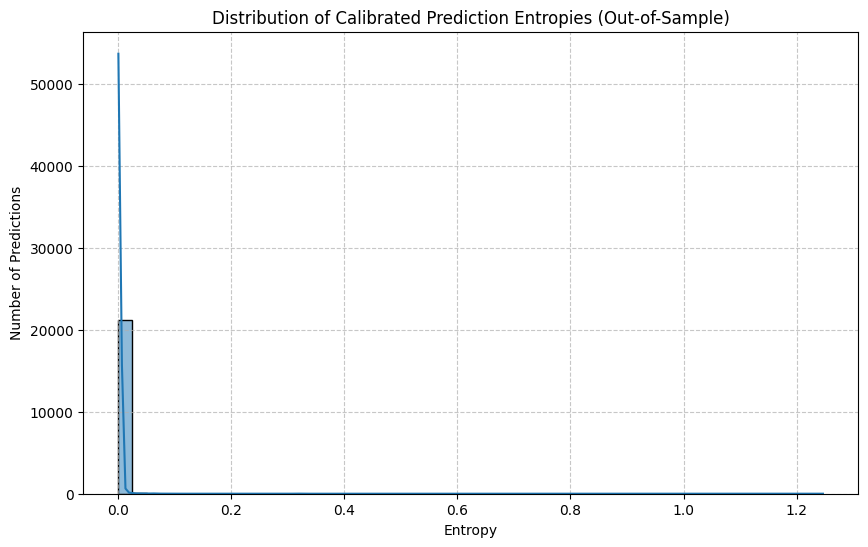

Calibrated Average Entropy: 0.0017
Calibrated Min Entropy: 0.0000
Calibrated Max Entropy: 1.2467

Calibrated Prediction with Highest Entropy (index 14373):
True Label: 6
Predicted Label: 8
Probabilities: [1.1666730e-01 5.3171790e-03 2.8358868e-15 1.9733835e-04 1.2802600e-03
 9.7088680e-02 3.3516890e-01 4.2468923e-04 4.4370168e-01 1.5404934e-04]
Entropy: 1.2467

Calibrated Prediction with Lowest Entropy (index 5381):
True Label: 2
Predicted Label: 2
Probabilities: [8.4033985e-36 0.0000000e+00 1.0000000e+00 2.2112708e-38 0.0000000e+00
 1.4072721e-35 0.0000000e+00 1.9987469e-37 8.1079282e-37 0.0000000e+00]
Entropy: 0.0000


In [11]:
from scipy.stats import entropy
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

# Get raw logits from the calibrated model for test data
calibrated_logits = calibrated_model.predict(x_test, verbose=0)

# Apply softmax to get probabilities
y_test_probs_calibrated = tf.nn.softmax(calibrated_logits).numpy()

# Calculate entropy for each calibrated prediction
entropies_calibrated = entropy(y_test_probs_calibrated, axis=1)

# Plot histogram of calibrated entropies
plt.figure(figsize=(10, 6))
sns.histplot(entropies_calibrated, bins=50, kde=True)
plt.title('Distribution of Calibrated Prediction Entropies (Out-of-Sample)')
plt.xlabel('Entropy')
plt.ylabel('Number of Predictions')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

print(f"Calibrated Average Entropy: {np.mean(entropies_calibrated):.4f}")
print(f"Calibrated Min Entropy: {np.min(entropies_calibrated):.4f}")
print(f"Calibrated Max Entropy: {np.max(entropies_calibrated):.4f}")

# Example: Find indices of highest and lowest entropy calibrated predictions
highest_entropy_idx_calibrated = np.argmax(entropies_calibrated)
lowest_entropy_idx_calibrated = np.argmin(entropies_calibrated)

print(f"\nCalibrated Prediction with Highest Entropy (index {highest_entropy_idx_calibrated}):")
print(f"True Label: {y_test_true[highest_entropy_idx_calibrated]}")
print(f"Predicted Label: {np.argmax(y_test_probs_calibrated[highest_entropy_idx_calibrated])}")
print(f"Probabilities: {y_test_probs_calibrated[highest_entropy_idx_calibrated]}")
print(f"Entropy: {entropies_calibrated[highest_entropy_idx_calibrated]:.4f}")

print(f"\nCalibrated Prediction with Lowest Entropy (index {lowest_entropy_idx_calibrated}):")
print(f"True Label: {y_test_true[lowest_entropy_idx_calibrated]}")
print(f"Predicted Label: {np.argmax(y_test_probs_calibrated[lowest_entropy_idx_calibrated])}")
print(f"Probabilities: {y_test_probs_calibrated[lowest_entropy_idx_calibrated]}")
print(f"Entropy: {entropies_calibrated[lowest_entropy_idx_calibrated]:.4f}")


##### Calculate and Plot the Expected Calliberation Error (ECE)

In [12]:
from sklearn.calibration import calibration_curve
import numpy as np

def calculate_ece(y_true_multiclass, y_prob_matrix, n_bins=10):
    # Get the predicted class (the one with the highest probability)
    y_pred = np.argmax(y_prob_matrix, axis=1)
    # Get the confidence for the predicted class
    confidence = np.max(y_prob_matrix, axis=1)

    # Create a binary y_true: 1 if the prediction was correct, 0 otherwise
    y_true_binary = (y_true_multiclass == y_pred).astype(int)

    ece = 0.0
    total_samples = len(confidence)

    if total_samples == 0:
        return 0.0

    # Define bin boundaries
    bin_boundaries = np.linspace(0.0, 1.0, n_bins + 1)
    bin_lowers = bin_boundaries[:-1]
    bin_uppers = bin_boundaries[1:]

    for i in range(n_bins):
        # Identify samples in the current bin
        # Use <= for upper bound to include 1.0 in the last bin
        if i == n_bins - 1:
            in_bin = (confidence > bin_lowers[i]) & (confidence <= bin_uppers[i])
        else:
            in_bin = (confidence > bin_lowers[i]) & (confidence < bin_uppers[i])

        num_in_bin = np.sum(in_bin)

        if num_in_bin > 0:
            accuracy_in_bin = np.mean(y_true_binary[in_bin])
            avg_confidence_in_bin = np.mean(confidence[in_bin])
            prop_in_bin = num_in_bin / total_samples
            ece += np.abs(accuracy_in_bin - avg_confidence_in_bin) * prop_in_bin

    return ece

# Calculate ECE for original model
ece_original = calculate_ece(y_test_true, y_test_probs)
print(f"Original Model ECE: {ece_original:.4f}")

# Calculate ECE for calibrated model
ece_calibrated = calculate_ece(y_test_true, y_test_probs_calibrated)
print(f"Calibrated Model ECE: {ece_calibrated:.4f}")

Original Model ECE: 0.0003
Calibrated Model ECE: 0.0006


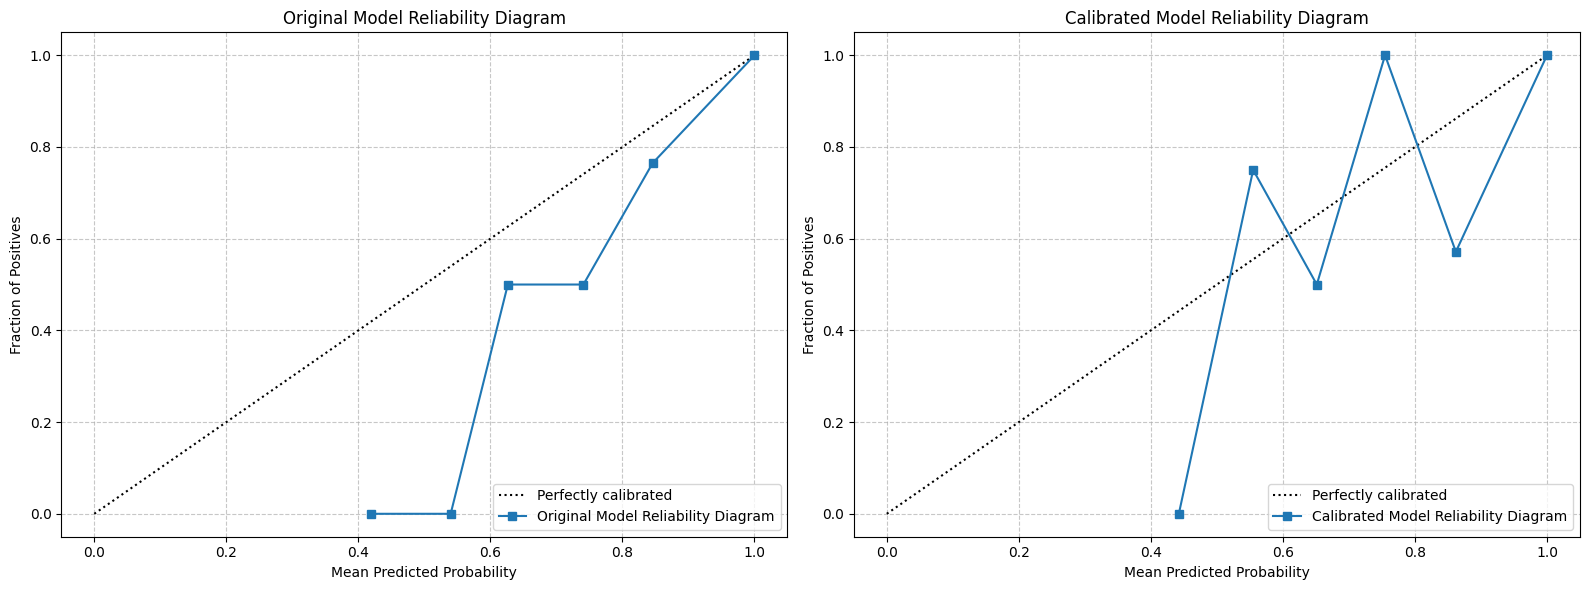

In [13]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

def plot_reliability_diagram(y_true_multiclass, y_prob_matrix, title, ax, n_bins=10):
    # Get the predicted class (the one with the highest probability)
    y_pred = np.argmax(y_prob_matrix, axis=1)
    # Get the confidence for the predicted class
    confidence = np.max(y_prob_matrix, axis=1)

    # Create a binary y_true: 1 if the prediction was correct, 0 otherwise
    y_true_binary = (y_true_multiclass == y_pred).astype(int)

    # Use the binary y_true and confidence for calibration_curve
    prob_true, prob_pred = calibration_curve(y_true_binary, confidence, n_bins=n_bins, strategy='uniform', pos_label=1)

    ax.plot([0, 1], [0, 1], 'k:', label='Perfectly calibrated')
    ax.plot(prob_pred, prob_true, 's-', label=title)
    ax.set_xlabel('Mean Predicted Probability')
    ax.set_ylabel('Fraction of Positives')
    ax.set_title(title)
    ax.legend(loc='lower right')
    ax.grid(True, linestyle='--', alpha=0.7)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Reliability diagram for Original Model
plot_reliability_diagram(y_test_true,
                         y_test_probs,
                         'Original Model Reliability Diagram',
                         axes[0])

# Reliability diagram for Calibrated Model
plot_reliability_diagram(y_test_true,
                         y_test_probs_calibrated,
                         'Calibrated Model Reliability Diagram',
                         axes[1])

plt.tight_layout()
plt.show()


#### Calculate And Plot the Brier Score

Original Model Brier Score: 0.0009
Calibrated Model Brier Score: 0.0016


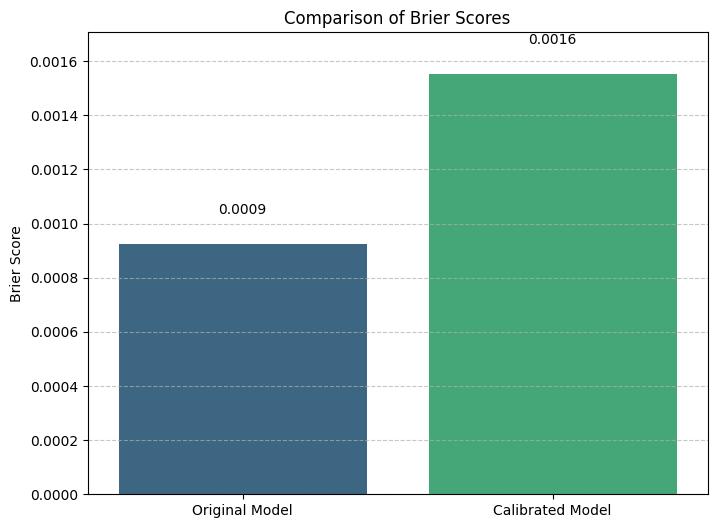

In [14]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import brier_score_loss

def calculate_multiclass_brier_score(y_true_multiclass, y_prob_matrix):
    # One-hot encode the true labels
    num_classes = y_prob_matrix.shape[1]
    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    y_true_one_hot = ohe.fit_transform(y_true_multiclass.reshape(-1, 1))

    # Calculate the squared difference for each class and sum them up
    brier_score = np.mean(np.sum((y_prob_matrix - y_true_one_hot)**2, axis=1))
    return brier_score

# Calculate Brier Score for original model
brier_original = calculate_multiclass_brier_score(y_test_true, y_test_probs)
print(f"Original Model Brier Score: {brier_original:.4f}")

# Calculate Brier Score for calibrated model
brier_calibrated = calculate_multiclass_brier_score(y_test_true, y_test_probs_calibrated)
print(f"Calibrated Model Brier Score: {brier_calibrated:.4f}")

import matplotlib.pyplot as plt
import seaborn as sns

# Create a bar plot to compare Brier Scores
scores = [brier_original, brier_calibrated]
labels = ['Original Model', 'Calibrated Model']

plt.figure(figsize=(8, 6))
sns.barplot(x=labels, y=scores, palette='viridis', hue=labels, legend=False)
plt.title('Comparison of Brier Scores')
plt.ylabel('Brier Score')
plt.ylim(0, max(scores) * 1.1) # Set y-limit to slightly above max score

for i, score in enumerate(scores):
    plt.text(i, score + 0.0001, f'{score:.4f}', ha='center', va='bottom')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### Class-wise Expected Calibration Error (ECE) and Brier Scor

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def calculate_ece_per_class(y_true_multiclass, y_prob_matrix, class_idx, n_bins=10):
    """
    Calculates the Expected Calibration Error for a specific class.
    Treats the problem as binary: is it `class_idx` or not `class_idx`?
    """
    # Confidence for the specific class (predicted probability for that class)
    confidence = y_prob_matrix[:, class_idx]
    # Binary true labels for the specific class (1 if true class, 0 otherwise)
    y_true_binary = (y_true_multiclass == class_idx).astype(int)

    ece = 0.0
    total_samples = len(confidence)

    if total_samples == 0:
        return 0.0

    bin_boundaries = np.linspace(0.0, 1.0, n_bins + 1)
    bin_lowers = bin_boundaries[:-1]
    bin_uppers = bin_boundaries[1:]

    for i in range(n_bins):
        # Identify samples in the current bin based on class confidence
        if i == n_bins - 1:
            # Include 1.0 in the last bin
            in_bin = (confidence >= bin_lowers[i]) & (confidence <= bin_uppers[i])
        else:
            in_bin = (confidence >= bin_lowers[i]) & (confidence < bin_uppers[i])

        num_in_bin = np.sum(in_bin)

        if num_in_bin > 0:
            # Accuracy in bin: fraction of true positives for this class in this confidence bin
            accuracy_in_bin = np.mean(y_true_binary[in_bin])
            # Average confidence in bin: average predicted probability for this class in this bin
            avg_confidence_in_bin = np.mean(confidence[in_bin])
            prop_in_bin = num_in_bin / total_samples
            ece += np.abs(accuracy_in_bin - avg_confidence_in_bin) * prop_in_bin
    return ece

def calculate_brier_score_per_class(y_true_multiclass, y_prob_matrix, class_idx):
    """
    Calculates the Brier Score for a specific class.
    """
    # True binary labels for the specific class
    y_true_binary = (y_true_multiclass == class_idx).astype(int)
    # Predicted probabilities for the specific class
    y_pred_prob_class = y_prob_matrix[:, class_idx]

    # Brier score is the mean squared difference between predicted probability and true binary outcome
    brier_score = np.mean((y_pred_prob_class - y_true_binary)**2)
    return brier_score

# Prepare to store results
classes = range(10)
original_ece_per_class = []
calibrated_ece_per_class = []
original_brier_per_class = []
calibrated_brier_per_class = []

print("Calculating class-wise ECE and Brier Scores...")

for i in classes:
    # Calculate ECE per class
    ece_orig = calculate_ece_per_class(y_test_true, y_test_probs, i)
    ece_calib = calculate_ece_per_class(y_test_true, y_test_probs_calibrated, i)
    original_ece_per_class.append(ece_orig)
    calibrated_ece_per_class.append(ece_calib)

    # Calculate Brier Score per class
    brier_orig = calculate_brier_score_per_class(y_test_true, y_test_probs, i)
    brier_calib = calculate_brier_score_per_class(y_test_true, y_test_probs_calibrated, i)
    original_brier_per_class.append(brier_orig)
    calibrated_brier_per_class.append(brier_calib)

    print(f"\nClass {i}:")
    print(f"  Original ECE: {ece_orig:.4f}, Calibrated ECE: {ece_calib:.4f}")
    print(f"  Original Brier: {brier_orig:.4f}, Calibrated Brier: {brier_calib:.4f}")

print("\nClass-wise calculations complete.")

Calculating class-wise ECE and Brier Scores...

Class 0:
  Original ECE: 0.0002, Calibrated ECE: 0.0002
  Original Brier: 0.0001, Calibrated Brier: 0.0002

Class 1:
  Original ECE: 0.0002, Calibrated ECE: 0.0002
  Original Brier: 0.0002, Calibrated Brier: 0.0002

Class 2:
  Original ECE: 0.0000, Calibrated ECE: 0.0002
  Original Brier: 0.0000, Calibrated Brier: 0.0002

Class 3:
  Original ECE: 0.0001, Calibrated ECE: 0.0001
  Original Brier: 0.0001, Calibrated Brier: 0.0000

Class 4:
  Original ECE: 0.0000, Calibrated ECE: 0.0000
  Original Brier: 0.0000, Calibrated Brier: 0.0000

Class 5:
  Original ECE: 0.0002, Calibrated ECE: 0.0002
  Original Brier: 0.0001, Calibrated Brier: 0.0002

Class 6:
  Original ECE: 0.0001, Calibrated ECE: 0.0003
  Original Brier: 0.0001, Calibrated Brier: 0.0003

Class 7:
  Original ECE: 0.0001, Calibrated ECE: 0.0003
  Original Brier: 0.0001, Calibrated Brier: 0.0003

Class 8:
  Original ECE: 0.0001, Calibrated ECE: 0.0002
  Original Brier: 0.0001, Calibr

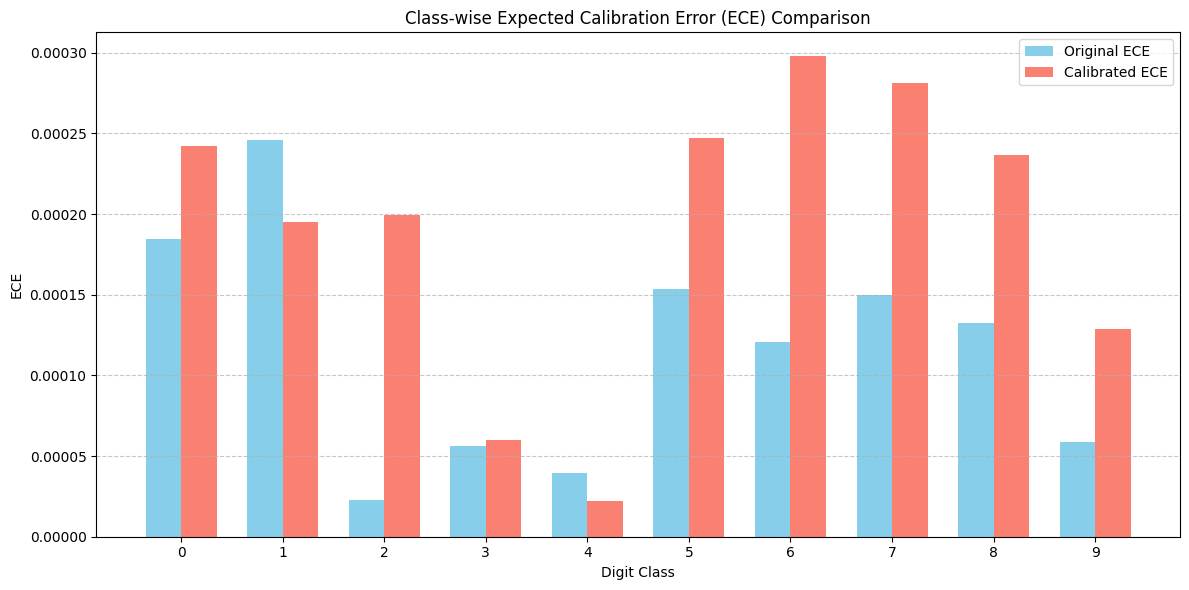

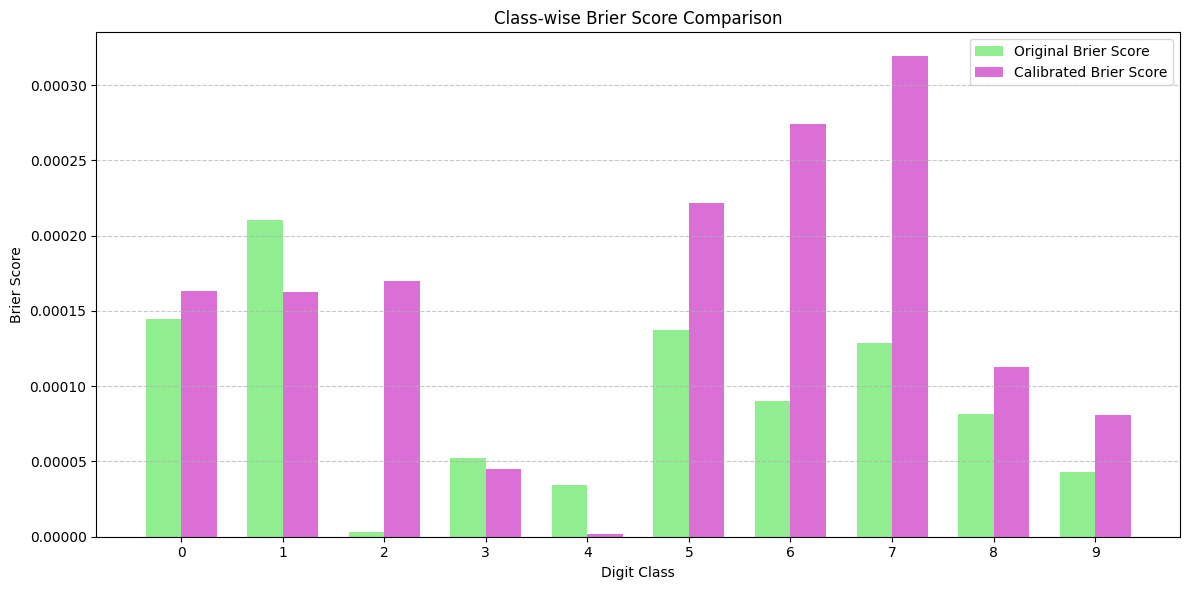

In [16]:
# Plotting Class-wise ECE
plt.figure(figsize=(12, 6))
bar_width = 0.35
index = np.arange(len(classes))

plt.bar(index, original_ece_per_class, bar_width, label='Original ECE', color='skyblue')
plt.bar(index + bar_width, calibrated_ece_per_class, bar_width, label='Calibrated ECE', color='salmon')

plt.xlabel('Digit Class')
plt.ylabel('ECE')
plt.title('Class-wise Expected Calibration Error (ECE) Comparison')
plt.xticks(index + bar_width / 2, classes)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Plotting Class-wise Brier Score
plt.figure(figsize=(12, 6))
plt.bar(index, original_brier_per_class, bar_width, label='Original Brier Score', color='lightgreen')
plt.bar(index + bar_width, calibrated_brier_per_class, bar_width, label='Calibrated Brier Score', color='orchid')

plt.xlabel('Digit Class')
plt.ylabel('Brier Score')
plt.title('Class-wise Brier Score Comparison')
plt.xticks(index + bar_width / 2, classes)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### Analyze Specific Cases Where Calibration Had a Significant Impact

--- Analyzing specific cases of calibration impact ---

Sample with Highest Original Entropy (Index: 12236)


/tmp/ipykernel_2889/4253082095.py:38: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


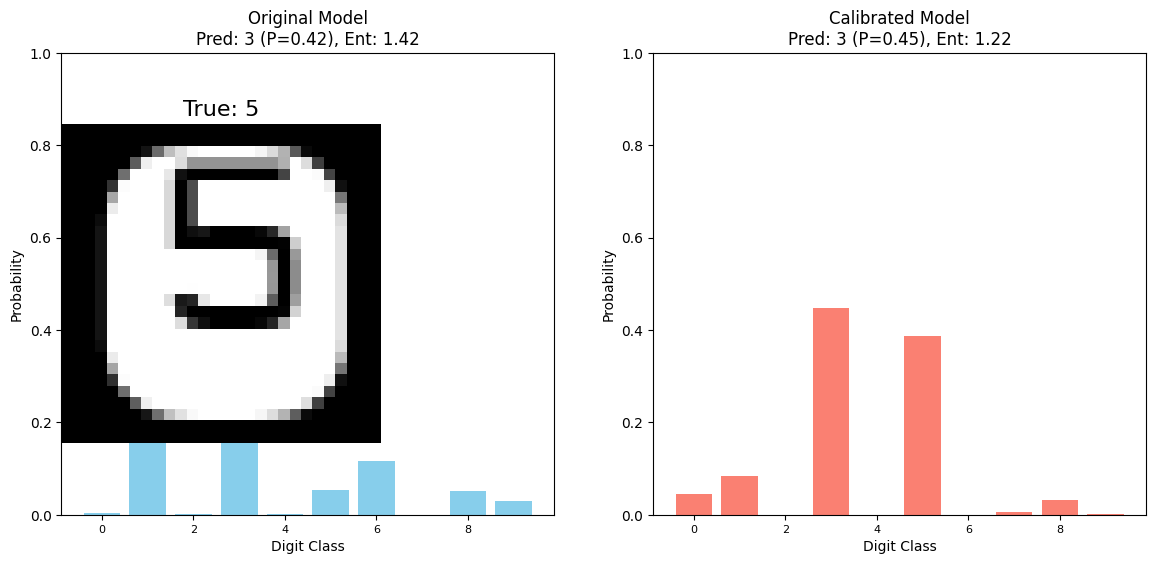


Sample where Calibration Most Reduced Entropy (Index: 13415)


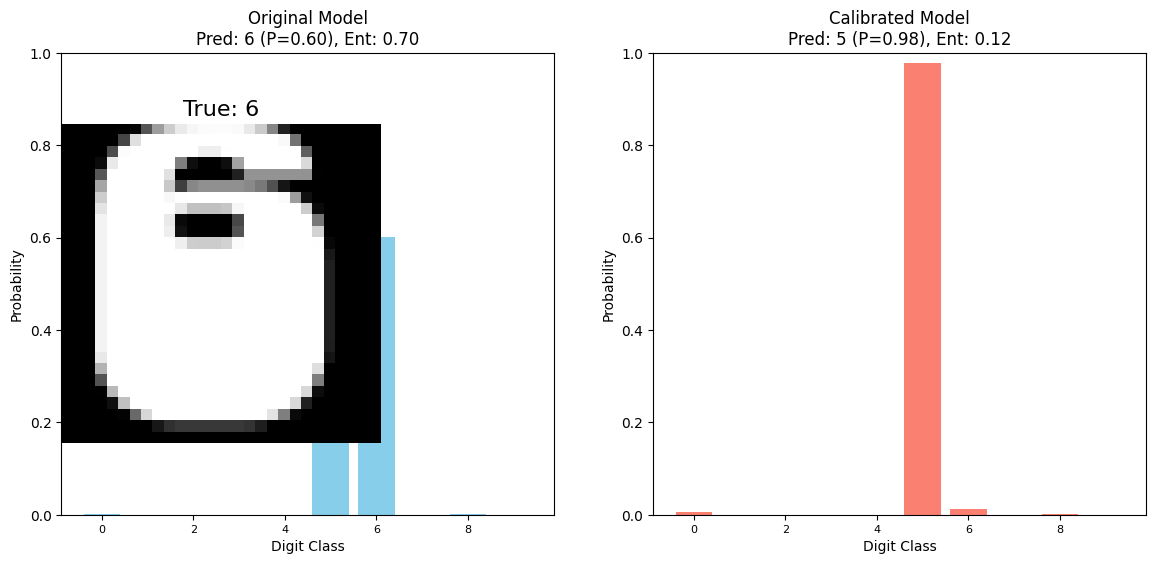


Sample where Calibration Most Increased Entropy (Index: 14373)


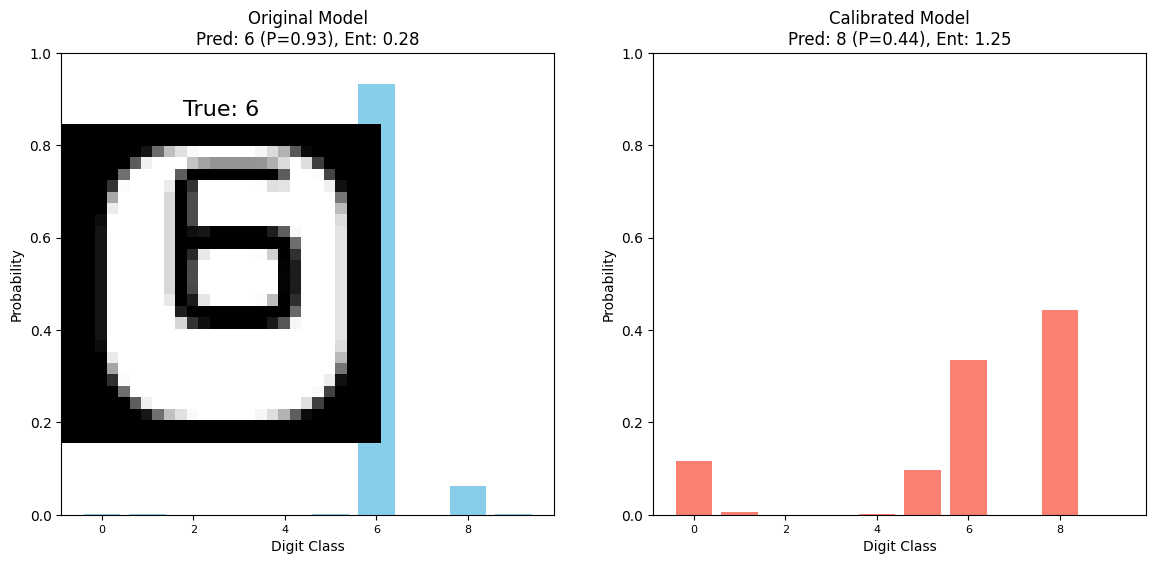

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_prediction_comparison(idx, x_test_img, y_true_label, original_probs, original_entropy, calibrated_probs, calibrated_entropy):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Display the image
    ax_img = fig.add_subplot(1, 3, 1) # Use 1,3,1 for image placement
    ax_img.imshow(x_test_img.reshape(28, 28), cmap='gray')
    ax_img.set_title(f"True: {y_true_label}", fontsize=16)
    ax_img.axis('off')

    # Original Model Predictions
    original_pred_label = np.argmax(original_probs)
    original_pred_prob = original_probs[original_pred_label]

    # Calibrated Model Predictions
    calibrated_pred_label = np.argmax(calibrated_probs)
    calibrated_pred_prob = calibrated_probs[calibrated_pred_label]

    # Bar plot for Original Model
    axes[0].bar(range(10), original_probs, color='skyblue')
    axes[0].set_title(f"Original Model\nPred: {original_pred_label} (P={original_pred_prob:.2f}), Ent: {original_entropy:.2f}")
    axes[0].set_xlabel("Digit Class")
    axes[0].set_ylabel("Probability")
    axes[0].set_ylim(0, 1)
    axes[0].tick_params(axis='x', labelsize=8)

    # Bar plot for Calibrated Model
    axes[1].bar(range(10), calibrated_probs, color='salmon')
    axes[1].set_title(f"Calibrated Model\nPred: {calibrated_pred_label} (P={calibrated_pred_prob:.2f}), Ent: {calibrated_entropy:.2f}")
    axes[1].set_xlabel("Digit Class")
    axes[1].set_ylabel("Probability")
    axes[1].set_ylim(0, 1)
    axes[1].tick_params(axis='x', labelsize=8)

    plt.tight_layout()
    plt.show()

print("--- Analyzing specific cases of calibration impact ---")

# Case 1: Sample with the highest original entropy (most uncertain)
# This index was already found during the initial entropy analysis
highest_entropy_idx = np.argmax(entropies)
print(f"\nSample with Highest Original Entropy (Index: {highest_entropy_idx})")
plot_prediction_comparison(
    highest_entropy_idx,
    x_test[highest_entropy_idx],
    y_test_true[highest_entropy_idx],
    y_test_probs[highest_entropy_idx],
    entropies[highest_entropy_idx],
    y_test_probs_calibrated[highest_entropy_idx],
    entropies_calibrated[highest_entropy_idx]
)

# Case 2: Sample where calibration significantly REDUCED uncertainty (highest entropy_reduction)
# Calculate difference: positive value means entropy decreased after calibration
entropy_reduction = entropies - entropies_calibrated
idx_max_reduction = np.argmax(entropy_reduction)

print(f"\nSample where Calibration Most Reduced Entropy (Index: {idx_max_reduction})")
plot_prediction_comparison(
    idx_max_reduction,
    x_test[idx_max_reduction],
    y_test_true[idx_max_reduction],
    y_test_probs[idx_max_reduction],
    entropies[idx_max_reduction],
    y_test_probs_calibrated[idx_max_reduction],
    entropies_calibrated[idx_max_reduction]
)

# Case 3: Sample where calibration significantly INCREASED uncertainty (highest entropy_increase)
# Calculate difference: negative value means entropy increased after calibration
idx_max_increase = np.argmin(entropy_reduction) # min of (original - calibrated) means max increase

print(f"\nSample where Calibration Most Increased Entropy (Index: {idx_max_increase})")
plot_prediction_comparison(
    idx_max_increase,
    x_test[idx_max_increase],
    y_test_true[idx_max_increase],
    y_test_probs[idx_max_increase],
    entropies[idx_max_increase],
    y_test_probs_calibrated[idx_max_increase],
    entropies_calibrated[idx_max_increase]
)

#### Summary Table: Original vs. Calibrated Metrics Per Class

In [18]:
import pandas as pd

# Create a dictionary to hold the data
summary_data = {
    'Class': classes,
    'Original ECE': original_ece_per_class,
    'Calibrated ECE': calibrated_ece_per_class,
    'Original Brier': original_brier_per_class,
    'Calibrated Brier': calibrated_brier_per_class
}

# Create a DataFrame
summary_df = pd.DataFrame(summary_data)

# Display the DataFrame
print("Summary Table: Original vs. Calibrated Metrics Per Class")
display(summary_df)

Summary Table: Original vs. Calibrated Metrics Per Class


,Class,Original ECE,Calibrated ECE,Original Brier,Calibrated Brier
0,0,0.000185,0.000242,0.000144,0.000163
1,1,0.000246,0.000195,0.000210,0.000163
2,2,0.000023,0.000200,0.000003,0.000170
3,3,0.000057,0.000060,0.000052,0.000045
4,4,0.000040,0.000022,0.000035,0.000002
5,5,0.000154,0.000247,0.000138,0.000221
6,6,0.000121,0.000298,0.000090,0.000274
7,7,0.000150,0.000281,0.000129,0.000319
8,8,0.000133,0.000237,0.000082,0.000113
9,9,0.000059,0.000129,0.000043,0.000081


#### Mean Metrics Comparison: Original vs. Calibrated Models

In [19]:
import numpy as np
import pandas as pd

# Calculate mean ECE and Brier Scores across all classes
mean_original_ece = np.mean(original_ece_per_class)
mean_calibrated_ece = np.mean(calibrated_ece_per_class)

mean_original_brier = np.mean(original_brier_per_class)
mean_calibrated_brier = np.mean(calibrated_brier_per_class)

# Create a DataFrame for comparison
mean_metrics_df = pd.DataFrame({
    'Metric': ['Mean ECE', 'Mean Brier Score'],
    'Original Model': [mean_original_ece, mean_original_brier],
    'Calibrated Model': [mean_calibrated_ece, mean_calibrated_brier]
})

print("\nOverall Mean Metrics Comparison:")
display(mean_metrics_df.round(6))

print(f"\nPercentage Reduction in Mean ECE: {((mean_original_ece - mean_calibrated_ece) / mean_original_ece * 100):.2f}%")
print(f"Percentage Reduction in Mean Brier Score: {((mean_original_brier - mean_calibrated_brier) / mean_original_brier * 100):.2f}%")



Overall Mean Metrics Comparison:


,Metric,Original Model,Calibrated Model
0,Mean ECE,0.000117,0.000191
1,Mean Brier Score,0.000093,0.000155



Percentage Reduction in Mean ECE: -63.94%
Percentage Reduction in Mean Brier Score: -67.60%


In [27]:
import os

# Define a path to save the calibrated model
save_path = '/content/emnist_calibrated_model.keras'

# Save the model
loaded_model.save(save_path)

print(f"Calibrated model saved successfully to {save_path}")
print(f"File size: {os.path.getsize(save_path) / (1024*1024):.2f} MB")

Calibrated model saved successfully to /content/emnist_calibrated_model.keras
File size: 3.02 MB


In [28]:
import os

# Define the path where the calibrated model was saved
save_path = '/content/emnist_calibrated_model.keras'

# Load the calibrated model
reloaded_calibrated_model = tf.keras.models.load_model(save_path)

print("Calibrated model reloaded successfully!")

# Display the summary of the reloaded model to verify its structure
reloaded_calibrated_model.summary()

Calibrated model reloaded successfully!


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 38 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "vector_scaler"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ functional_4 (Functional)       │ (None, 10)             │       740,685 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,474,145 (5.62 MB)

 Trainable params: 733,438 (2.80 MB)

 Non-trainable params: 7,267 (28.39 KB)

 Optimizer params: 733,440 (2.80 MB)